# Sol, agua de mar y una torre de seis pisos

**11,5 veces más uranio.** Eso es lo que gana este aparato cuando le pega el sol, comparado con el mismo aparato a oscuras — en una solución de laboratorio dopada con 2,5 mg/L del ion que se quiere pescar. El litio sube 10,1 veces.

Vamos a desarmar ese número con los datos que el propio equipo publicó: de dónde sale, en cuántas piezas se parte, y qué le queda cuando lo bajan de la mesa del laboratorio a un patio de Shenzhen con agua de mar de verdad.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

|  |  |
| --- | --- |
| **Paper** | *Solar-powered resource separator for clean water production, electricity generation and critical resource recovery* |
| **Revista** | Nature Water (2026) |
| **DOI** | [10.1038/s44221-026-00700-2](https://doi.org/10.1038/s44221-026-00700-2) |
| **Datos** | Source Data (MOESM2) y Supplementary Information del mismo artículo |

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-01-separador-solar-litio-uranio/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/0M1k80kh0UE)

## Qué construyeron

Una torre de seis cámaras apiladas, flotando sobre agua de mar. El sol calienta la de arriba, el agua se evapora, y al condensarse en el techo de la cámara siguiente suelta el calor que traía — calor que vuelve a evaporar agua un piso más abajo. Seis veces. Eso es la *recuperación de calor latente multietapa* del título: reusar el mismo paquete de calor, piso por piso, en lugar de tirarlo al aire.

Mientras eso pasa, tres cosas más ocurren en paralelo:

- El agua condensada sale dulce.
- Unas telas adsorbentes en las paredes —una diseñada para litio, otra para uranio— van pegando iones del agua que queda.
- Un módulo termoeléctrico aprovecha la diferencia de temperatura entre pisos y saca electricidad.

Los autores lo **proponen** como una sola pieza que hace las cuatro cosas a la vez. Nosotros abrimos los datos crudos y vemos hasta dónde llegan.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SOL_LABORATORIO = 1.0        # kW m-2 — el "1 sol" estándar con el que se midió el paper
VIDA_MECHA_ANIOS = 5         # años de vida útil de la mecha capilar (análisis económico)
CAMARA_REFERENCIA = 1        # cámara contra la que normalizamos el gradiente

FUENTE = 'Fuente: Yu et al. (2026), Nature Water | Datos: Source Data (MOESM2) + Supplementary Information'
COLOR_DATOS = '#2563EB'      # uranio
COLOR_SECUNDARIO = '#059669' # litio
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo editorial CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Descarga automática de los CSV si se ejecuta fuera del repo (Colab)
ARCHIVOS = ['ac_vs_irradiancia', 'rendimiento_por_etapas', 'ciclos_estabilidad',
            'dia_exterior', 'flujo_solar_exterior', 'camaras_agua_natural',
            'ingreso_neto_anual']
os.makedirs('datos', exist_ok=True)
for nombre in ARCHIVOS:
    destino = f'datos/{nombre}.csv'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(
            f'{BASE}/papers/2026-09-01-separador-solar-litio-uranio/datos/{nombre}.csv', destino)

irr    = pd.read_csv('datos/ac_vs_irradiancia.csv')      # AC monoetapa vs flujo solar
etapas = pd.read_csv('datos/rendimiento_por_etapas.csv') # 1-6 etapas bajo 1 sol
ciclos = pd.read_csv('datos/ciclos_estabilidad.csv')     # 20 ciclos de ~2 días
dia    = pd.read_csv('datos/dia_exterior.csv')           # jornada exterior, 5 ventanas de 2 h
flujo  = pd.read_csv('datos/flujo_solar_exterior.csv')   # flujo solar de esa jornada
cam    = pd.read_csv('datos/camaras_agua_natural.csv')   # gradiente por cámara, agua NATURAL
econ   = pd.read_csv('datos/ingreso_neto_anual.csv')     # sensibilidad del ingreso anual

# ── Los tres estados que arman el titular ─────────────────────────────
# Oscuridad viene del barrido de irradiancia (0 sun); las dos configuraciones
# bajo 1 sol vienen del barrido de etapas, para que ambos factores salgan del
# mismo experimento y no mezclemos paneles.
oscuras   = irr[irr.flujo_solar_sun == 0.0].iloc[0]
una_etapa = etapas[etapas.etapas == 1].iloc[0]
seis      = etapas[etapas.etapas == 6].iloc[0]

luz_u,     luz_li     = una_etapa.ac_u_g_m2 / oscuras.ac_u_g_m2,   una_etapa.ac_li_g_m2 / oscuras.ac_li_g_m2
etapas_u,  etapas_li  = seis.ac_u_g_m2 / una_etapa.ac_u_g_m2,      seis.ac_li_g_m2 / una_etapa.ac_li_g_m2
total_u,   total_li   = seis.ac_u_g_m2 / oscuras.ac_u_g_m2,        seis.ac_li_g_m2 / oscuras.ac_li_g_m2

print('EL TITULAR, DESARMADO  (capacidad de adsorción, g m-2)')
print(f'  uranio: {oscuras.ac_u_g_m2:.2f} (oscuras) -> {una_etapa.ac_u_g_m2:.2f} (1 sol) -> {seis.ac_u_g_m2:.2f} (6 etapas)')
print(f'          luz x{luz_u:.2f}  *  etapas x{etapas_u:.2f}  =  x{total_u:.2f}   [abstract: x11,6 | cuerpo: x10,6]')
print(f'  litio : {oscuras.ac_li_g_m2:.2f} (oscuras) -> {una_etapa.ac_li_g_m2:.2f} (1 sol) -> {seis.ac_li_g_m2:.2f} (6 etapas)')
print(f'          luz x{luz_li:.2f}  *  etapas x{etapas_li:.2f}  =  x{total_li:.2f}   [abstract: x10,2 | cuerpo: x9,2]')

# ── Agua y electricidad al apilar cámaras ─────────────────────────────
ratio_wpr   = seis.wpr_kg_m2_h / una_etapa.wpr_kg_m2_h
cambio_pv   = 100 * (seis.pv_output_w - una_etapa.pv_output_w) / una_etapa.pv_output_w
marginal    = etapas.wpr_kg_m2_h.diff().dropna().values
print(f'\nAGUA vs ELECTRICIDAD al pasar de 1 a 6 etapas')
print(f'  agua        : {una_etapa.wpr_kg_m2_h:.2f} -> {seis.wpr_kg_m2_h:.2f} kg m-2 h-1  (x{ratio_wpr:.2f}, +{100*(ratio_wpr-1):.0f}%)')
print(f'  electricidad: {una_etapa.pv_output_w:.1f} -> {seis.pv_output_w:.1f} W m-2  ({cambio_pv:+.1f}%)')
print(f'  ganancia marginal por cámara añadida: {np.array2string(marginal, precision=2)} kg m-2 h-1')

# ── Estabilidad: 20 ciclos de ~2 días cada uno ────────────────────────
print(f'\nESTABILIDAD ({len(ciclos)} ciclos x ~2 días = ~40 días, agua de mar dopada)')
for etiqueta, col in [('agua', 'wpr_kg_m2_h'), ('uranio', 'ac_u_g_m2'), ('litio', 'ac_li_g_m2')]:
    c1, c20 = ciclos[col].iloc[0], ciclos[col].iloc[-1]
    # La diferencia entre puntas no distingue tendencia de ruido: hace falta
    # correlacionar la serie completa contra el número de ciclo.
    rho_c, p_c = stats.spearmanr(ciclos.ciclo, ciclos[col])
    print(f'  {etiqueta:<7}: {c1:.3f} -> {c20:.3f}  ({100*(c20-c1)/c1:+.2f}%)  media {ciclos[col].mean():.3f} ± {ciclos[col].std(ddof=1):.3f}'
          f'  | Spearman rho vs ciclo = {rho_c:+.3f} (p = {p_c:.2g})')

# ── Gradiente por cámara, en agua de mar NATURAL ──────────────────────
# Supplementary Table 4. La base del m-2 no está declarada en el SI, así que
# usamos esta tabla SOLO para el gradiente relativo cámara 1 -> cámara 6.
ref = cam[cam.camara == CAMARA_REFERENCIA].iloc[0]
cam['rel_u']  = 100 * cam.ac_u_mg_m2  / ref.ac_u_mg_m2
cam['rel_li'] = 100 * cam.ac_li_mg_m2 / ref.ac_li_mg_m2
caida_temp = ref.temperatura_c - cam.temperatura_c.iloc[-1]
ratio_cam_u  = ref.ac_u_mg_m2  / cam.ac_u_mg_m2.iloc[-1]
ratio_cam_li = ref.ac_li_mg_m2 / cam.ac_li_mg_m2.iloc[-1]
rho_u,  p_u  = stats.spearmanr(cam.temperatura_c, cam.ac_u_mg_m2)
rho_li, p_li = stats.spearmanr(cam.temperatura_c, cam.ac_li_mg_m2)
print(f'\nGRADIENTE POR CÁMARA (agua de mar natural, 7 días, 1 sol) — n = {len(cam)} cámaras')
print(f'  temperatura: {ref.temperatura_c:.1f} °C (cámara 1) -> {cam.temperatura_c.iloc[-1]:.1f} °C (cámara 6), caída de {caida_temp:.1f} °C')
print(f'  uranio: x{ratio_cam_u:.2f} entre cámara 1 y 6   | Spearman rho = {rho_u:.3f} (p = {p_u:.4f})')
print(f'  litio : x{ratio_cam_li:.2f} entre cámara 1 y 6   | Spearman rho = {rho_li:.3f} (p = {p_li:.4f})')
print('  OJO: son 6 cámaras del mismo aparato, no 6 experimentos independientes. Es descriptivo.')

# ── La jornada exterior en Shenzhen ───────────────────────────────────
dia['hora_num'] = dia.hora.str.slice(0, 2).astype(int)
pico = dia.loc[dia.pv_output_w.idxmax()]
wpa_recomputada = (dia.wpr_kg_m2_h * 2).sum()
print(f'\nJORNADA EXTERIOR (Shenzhen, agua de mar real SIN dopar, 5 ventanas de 2 h)')
print(f'  pico de salida eléctrica: {pico.pv_output_w:.1f} W m-2 en la ventana que cierra a las {pico.hora}')
print(f'  agua del día (reportada) : {dia.wpa_acum_kg_m2.iloc[-1]:.2f} kg m-2')
print(f'  agua del día (recomputada como suma de WPR x 2 h): {wpa_recomputada:.2f} kg m-2  -> desvío {100*(wpa_recomputada/dia.wpa_acum_kg_m2.iloc[-1]-1):.1f}%')
energia_dia = (dia.pv_output_w * 2).sum() / 1000
print(f'  energía eléctrica del día (misma cuenta, ventanas x 2 h): {energia_dia:.2f} kWh m-2')
print(f'    el material suplementario reporta 1,02 kWh m-2  -> desvío {100*(energia_dia/1.02-1):.1f}%')

sobre_1sol = int((flujo.flujo_solar_kw_m2 >= SOL_LABORATORIO).sum())
q1, q3 = flujo.flujo_solar_kw_m2.quantile([0.25, 0.75])
print(f'\nFLUJO SOLAR DE ESA JORNADA — n = {len(flujo)} mediciones ({flujo.hora_decimal.min():.2f} h a {flujo.hora_decimal.max():.2f} h)')
print(f'  media {flujo.flujo_solar_kw_m2.mean():.3f} kW m-2 | mediana {flujo.flujo_solar_kw_m2.median():.3f} | RIC {q1:.3f}-{q3:.3f} | máximo {flujo.flujo_solar_kw_m2.max():.3f}')
print(f'  mediciones que alcanzan el "1 sol" del laboratorio ({SOL_LABORATORIO:.1f} kW m-2): {sobre_1sol} de {len(flujo)}')

# ── Economía: el ingreso depende de cuánto dure la mecha ──────────────
ing = dict(zip(econ.vida_util_mecha_anios, econ.ingreso_neto_usd_m2_anio))
primer_20 = int(econ[econ.ingreso_neto_usd_m2_anio > 20].vida_util_mecha_anios.min())
print(f'\nINGRESO NETO ANUAL MODELADO (US$ m-2, según vida útil de la mecha capilar)')
print(f'  1 año: {ing[1]:.2f}  |  {VIDA_MECHA_ANIOS} años: {ing[VIDA_MECHA_ANIOS]:.2f}  |  20 años: {ing[20]:.2f}')
print(f'  primera vida útil que supera los US$20 m-2: {primer_20} años')

EL TITULAR, DESARMADO  (capacidad de adsorción, g m-2)
  uranio: 0.44 (oscuras) -> 1.44 (1 sol) -> 5.06 (6 etapas)
          luz x3.27  *  etapas x3.51  =  x11.50   [abstract: x11,6 | cuerpo: x10,6]
  litio : 0.71 (oscuras) -> 2.21 (1 sol) -> 7.17 (6 etapas)
          luz x3.11  *  etapas x3.24  =  x10.10   [abstract: x10,2 | cuerpo: x9,2]

AGUA vs ELECTRICIDAD al pasar de 1 a 6 etapas
  agua        : 1.26 -> 4.01 kg m-2 h-1  (x3.18, +218%)
  electricidad: 124.6 -> 122.1 W m-2  (-2.0%)
  ganancia marginal por cámara añadida: [1.01 0.76 0.51 0.3  0.17] kg m-2 h-1

ESTABILIDAD (20 ciclos x ~2 días = ~40 días, agua de mar dopada)
  agua   : 3.940 -> 3.860  (-2.03%)  media 3.859 ± 0.036  | Spearman rho vs ciclo = -0.142 (p = 0.55)
  uranio : 5.026 -> 4.884  (-2.82%)  media 4.923 ± 0.038  | Spearman rho vs ciclo = -0.946 (p = 3.1e-10)
  litio  : 7.158 -> 6.968  (-2.65%)  media 7.026 ± 0.054  | Spearman rho vs ciclo = -0.991 (p = 3.6e-17)

GRADIENTE POR CÁMARA (agua de mar natural, 7 días, 1

Empecemos por el titular.

Aquí está.

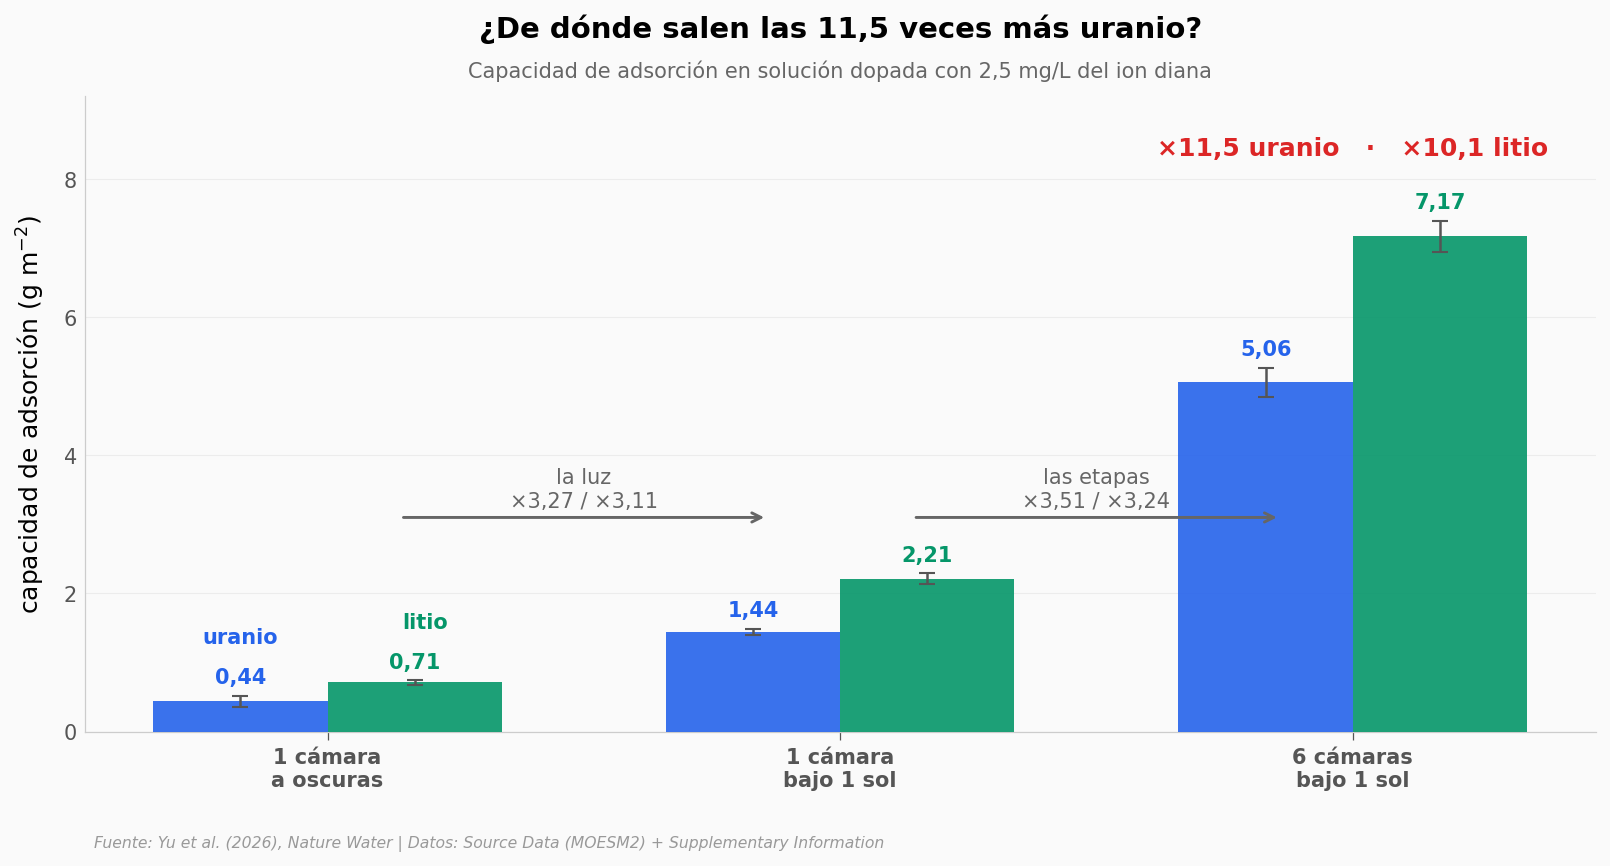

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

config = ['1 cámara\na oscuras', '1 cámara\nbajo 1 sol', '6 cámaras\nbajo 1 sol']
vals_u  = [oscuras.ac_u_g_m2,  una_etapa.ac_u_g_m2,  seis.ac_u_g_m2]
err_u   = [oscuras.ac_u_sd,    una_etapa.ac_u_sd,    seis.ac_u_sd]
vals_li = [oscuras.ac_li_g_m2, una_etapa.ac_li_g_m2, seis.ac_li_g_m2]
err_li  = [oscuras.ac_li_sd,   una_etapa.ac_li_sd,   seis.ac_li_sd]

x = np.arange(3)
w = 0.34
ax.bar(x - w/2, vals_u,  w, yerr=err_u,  color=COLOR_DATOS,      alpha=0.9,
       error_kw=dict(ecolor='#555555', capsize=4, lw=1.2), zorder=3)
ax.bar(x + w/2, vals_li, w, yerr=err_li, color=COLOR_SECUNDARIO, alpha=0.9,
       error_kw=dict(ecolor='#555555', capsize=4, lw=1.2), zorder=3)

# Valor sobre cada barra (coma decimal: convención española)
for xi, (vu, eu, vl, el) in enumerate(zip(vals_u, err_u, vals_li, err_li)):
    ax.text(xi - w/2, vu + eu + 0.18, f'{vu:.2f}'.replace('.', ','), ha='center',
            fontsize=10, fontweight='bold', color=COLOR_DATOS)
    ax.text(xi + w/2, vl + el + 0.18, f'{vl:.2f}'.replace('.', ','), ha='center',
            fontsize=10, fontweight='bold', color=COLOR_SECUNDARIO)

# Inline labels — reemplazan la caja de leyenda
ax.text(-w/2, vals_u[0] + err_u[0] + 0.75, 'uranio', ha='center', fontsize=10,
        fontweight='bold', color=COLOR_DATOS)
ax.text(w/2 + 0.02, vals_li[0] + err_li[0] + 0.75, 'litio', ha='center', fontsize=10,
        fontweight='bold', color=COLOR_SECUNDARIO)

# Las dos multiplicaciones, una por tramo
ax.annotate('', xy=(0.86, 3.1), xytext=(0.14, 3.1),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.4))
ax.text(0.5, 3.25, f'la luz\n×{luz_u:.2f} / ×{luz_li:.2f}'.replace('.', ','),
        ha='center', fontsize=10, color='#666666')
ax.annotate('', xy=(1.86, 3.1), xytext=(1.14, 3.1),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.4))
ax.text(1.5, 3.25, f'las etapas\n×{etapas_u:.2f} / ×{etapas_li:.2f}'.replace('.', ','),
        ha='center', fontsize=10, color='#666666')

ax.text(2, 8.35, f'×{total_u:.1f} uranio   ·   ×{total_li:.1f} litio'.replace('.', ','),
        ha='center', fontsize=12, fontweight='bold', color=COLOR_ALERTA)

ax.set_title('¿De dónde salen las 11,5 veces más uranio?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Capacidad de adsorción en solución dopada con 2,5 mg/L del ion diana',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(x)
ax.set_xticklabels(config, fontsize=10, fontweight='bold')
ax.set_ylabel('capacidad de adsorción (g m$^{-2}$)')
ax.set_ylim(0, 9.2)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/titular_desarmado.png', dpi=200, bbox_inches='tight')
plt.show()

## Dos trucos, no uno

Ese 11,5x —medido siempre en solución dopada con 2,5 mg/L, no en agua de mar— no es un efecto: son dos, y se multiplican.

**La luz** hace su parte. Con una sola cámara, pasar de oscuridad a un sol de laboratorio multiplica la captura de uranio por 3,27 y la de litio por 3,11. El calor pone el agua en movimiento y el agua arrastra los iones hacia la tela.

**Las etapas** hacen la otra. Apilar seis cámaras en vez de una vuelve a multiplicar: ×3,51 el uranio, ×3,24 el litio.

Y el producto es el titular: 3,27 × 3,51 = 11,5. 3,11 × 3,24 = 10,1. Los datos del Source Data se quedan a menos del 1% de los 11,6x y 10,2x que anuncia el resumen del artículo. Vale anotar una cosa que se ve al comparar: el párrafo de resultados del mismo paper reporta otra pareja de números para este salto —10,6x y 9,2x—, y son los del resumen los que cuadran con los datos publicados.

Separar los dos factores no es una manía de contabilidad. Uno de los dos tiene una consecuencia rara sobre lo demás que hace el aparato.

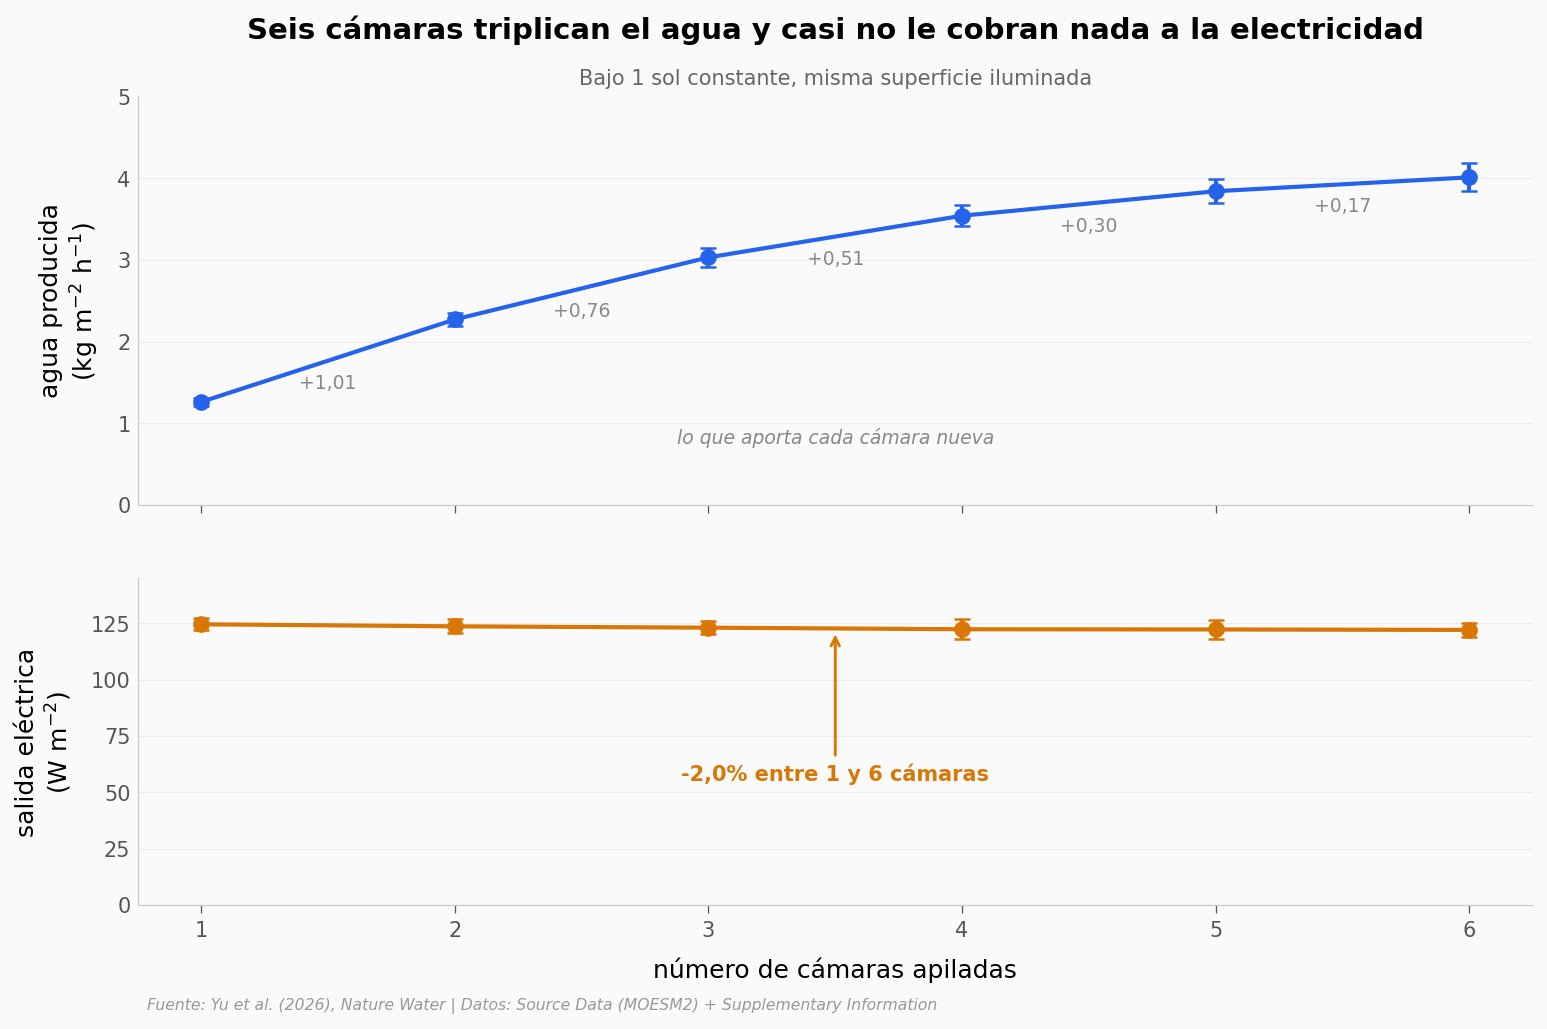

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1.25, 1]})

# Panel superior — el agua sube
ax1.errorbar(etapas.etapas, etapas.wpr_kg_m2_h, yerr=etapas.wpr_sd, fmt='o-',
             color=COLOR_DATOS, lw=2, capsize=4, capthick=1.2, zorder=5)
for i in range(len(etapas) - 1):
    x0, x1v = etapas.etapas.iloc[i], etapas.etapas.iloc[i+1]
    y0, y1v = etapas.wpr_kg_m2_h.iloc[i], etapas.wpr_kg_m2_h.iloc[i+1]
    ax1.text((x0 + x1v)/2, (y0 + y1v)/2 - 0.34, f'+{y1v - y0:.2f}'.replace('.', ','),
             ha='center', fontsize=9, color='#888888')
ax1.text(3.5, 0.75, 'lo que aporta cada cámara nueva', fontsize=9,
         color='#888888', style='italic', ha='center')
ax1.set_ylabel('agua producida\n(kg m$^{-2}$ h$^{-1}$)')
ax1.set_ylim(0, 5.0)
ax1.set_title('Seis cámaras triplican el agua y casi no le cobran nada a la electricidad',
              fontsize=14, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Bajo 1 sol constante, misma superficie iluminada',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

# Panel inferior — la electricidad no se mueve. Eje desde 0: una caída de
# 2,5 W autoescalada parecería un derrumbe.
ax2.errorbar(etapas.etapas, etapas.pv_output_w, yerr=etapas.pv_sd, fmt='o-',
             color=COLOR_REFERENCIA, lw=2, capsize=4, capthick=1.2, zorder=5)
ax2.set_ylim(0, 145)
ax2.set_ylabel('salida eléctrica\n(W m$^{-2}$)')
ax2.set_xlabel('número de cámaras apiladas')
ax2.set_xticks(etapas.etapas)
ax2.annotate(f'{cambio_pv:+.1f}% entre 1 y 6 cámaras'.replace('.', ','),
             xy=(3.5, 122), xytext=(3.5, 55), ha='center', fontsize=10,
             fontweight='bold', color=COLOR_REFERENCIA,
             arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.4))

fig.text(0.13, 0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/agua_vs_electricidad.png', dpi=200, bbox_inches='tight')
plt.show()

## El agua se triplica y la electricidad no se entera

De una cámara a seis, el agua pasa de 1,26 a 4,01 kg por metro cuadrado y hora: un 218% más. La salida eléctrica baja un 2,0%, de 124,6 a 122,1 W m⁻². Es la definición práctica de calor reciclado — el mismo paquete de energía haciendo el trabajo varias veces antes de escaparse.

Pero la curva se aplana sola. La segunda cámara aporta 1,01 kg m⁻² h⁻¹ extra; la sexta aporta 0,17. La curva explica sola por qué la torre se queda en seis: para una séptima cámara ya casi no quedaría calor útil que reusar.

Y ahí está el precio del truco. Si cada cámara vive del calor sobrante de la anterior, cada cámara está más fría que la anterior. Eso se ve piso por piso — y esta vez, en agua de mar natural, sin dopar.

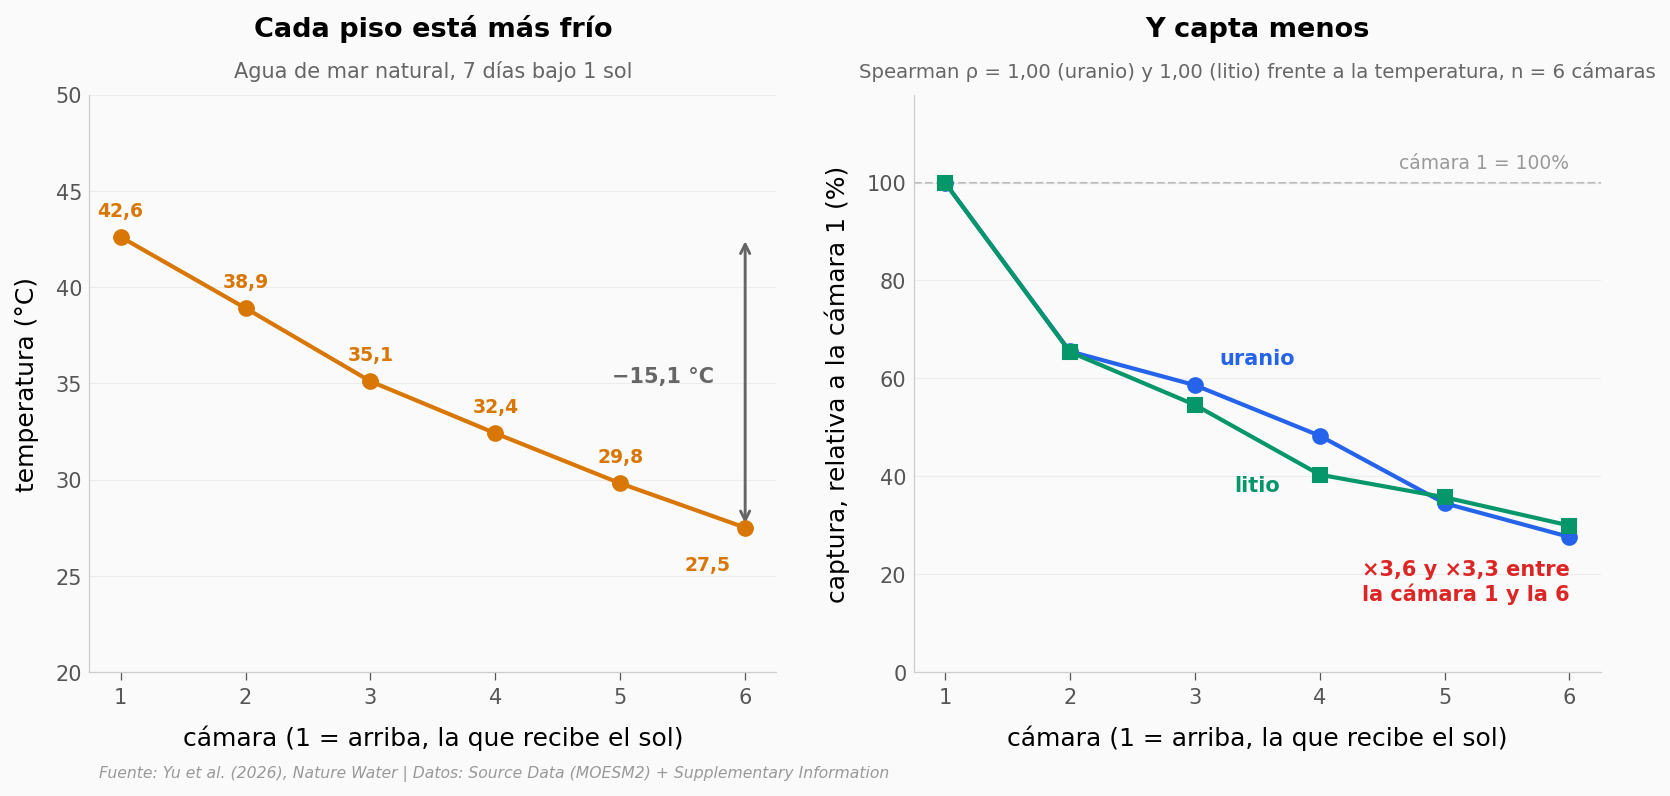

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda — la cadena se enfría
ax1.errorbar(cam.camara, cam.temperatura_c, yerr=cam.temperatura_sd, fmt='o-',
             color=COLOR_REFERENCIA, lw=2, capsize=4, capthick=1.2, zorder=5)
for _, r in cam.iterrows():
    # La última va abajo-izquierda para no chocar con la flecha de la caída
    dy, ha = (-2.2, 'right') if r.camara == cam.camara.max() else (1.1, 'center')
    ax1.text(r.camara - (0.12 if ha == 'right' else 0), r.temperatura_c + dy,
             f'{r.temperatura_c:.1f}'.replace('.', ','),
             ha=ha, fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')
ax1.annotate('', xy=(6, cam.temperatura_c.iloc[-1]), xytext=(6, ref.temperatura_c),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax1.text(5.75, (ref.temperatura_c + cam.temperatura_c.iloc[-1]) / 2,
         f'−{caida_temp:.1f} °C'.replace('.', ','), ha='right', fontsize=10,
         fontweight='bold', color='#666666')
ax1.set_xlabel('cámara (1 = arriba, la que recibe el sol)')
ax1.set_ylabel('temperatura (°C)')
ax1.set_ylim(20, 50)
ax1.set_xticks(cam.camara)
ax1.set_title('Cada piso está más frío', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Agua de mar natural, 7 días bajo 1 sol',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

# Derecha — y capta menos. Normalizado a la cámara 1, porque el SI no declara
# a qué superficie se refiere el m-2 de esta tabla (solo sirve el gradiente).
ax2.plot(cam.camara, cam.rel_u,  'o-', color=COLOR_DATOS,      lw=2, zorder=5)
ax2.plot(cam.camara, cam.rel_li, 's-', color=COLOR_SECUNDARIO, lw=2, zorder=5)
# Las dos series casi se tocan: etiquetamos en x=3,5, donde el hueco es mayor,
# una por encima y otra por debajo de ambas líneas.
ax2.text(3.5, 63, 'uranio', ha='center', fontsize=10, fontweight='bold',
         color=COLOR_DATOS)
ax2.text(3.5, 37, 'litio', ha='center', fontsize=10, fontweight='bold',
         color=COLOR_SECUNDARIO)
ax2.axhline(100, color=COLOR_CONTEXTO, lw=1, linestyle='--', zorder=1)
ax2.text(6, 103, 'cámara 1 = 100%', ha='right', fontsize=9, color='#999999')
ax2.text(6, cam.rel_u.iloc[-1] - 13,
         f'×{ratio_cam_u:.1f} y ×{ratio_cam_li:.1f} entre\nla cámara 1 y la 6'.replace('.', ','),
         ha='right', fontsize=10, fontweight='bold', color=COLOR_ALERTA)
ax2.set_xlabel('cámara (1 = arriba, la que recibe el sol)')
ax2.set_ylabel('captura, relativa a la cámara 1 (%)')
ax2.set_ylim(0, 118)
ax2.set_xticks(cam.camara)
ax2.set_title('Y capta menos', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, f'Spearman ρ = {rho_u:.2f} (uranio) y {rho_li:.2f} (litio) frente a la temperatura, n = 6 cámaras'.replace('.', ','),
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gradiente_camaras.png', dpi=200, bbox_inches='tight')
plt.show()

## El precio se paga abajo

La cámara 1 trabaja a 42,6 °C; la cámara 6, a 27,5 °C. Quince grados de caída a lo largo de la torre, y con ellos la captura se desploma: la cámara de arriba pega 3,6 veces más uranio y 3,3 veces más litio que la de abajo. La relación entre temperatura y captura es perfectamente ordenada (ρ = 1,00 en ambos metales), pero eso hay que leerlo con cuidado: son 6 cámaras del mismo aparato, no 6 experimentos independientes. Es una descripción del gradiente, no una prueba de causa.

Así que las seis etapas dan más agua *y* más captura total, pero con rendimientos cada vez peores por piso. El aparato compra volumen pagando eficiencia.

Hasta aquí, todo bajo un sol de laboratorio. La pregunta interesante es qué pasa afuera.

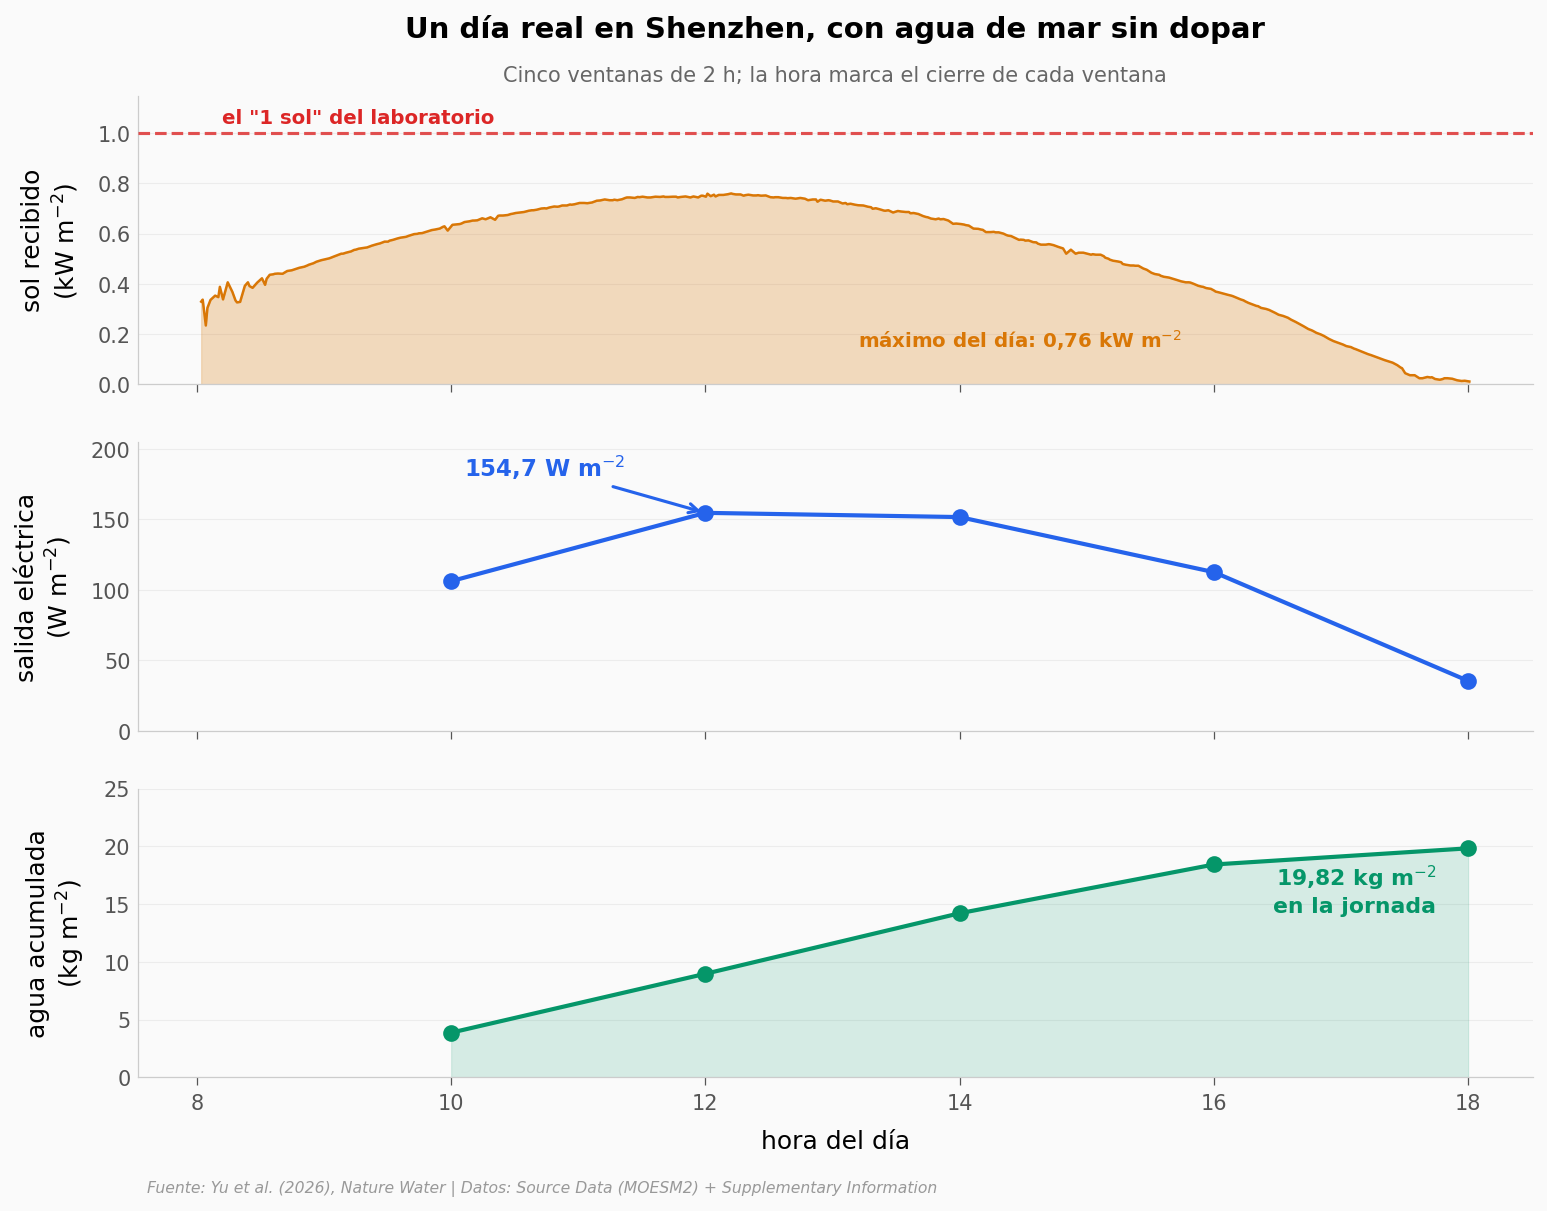

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 1, 1]})

# Panel 1 — el sol que hubo ese día (389 mediciones)
ax1.fill_between(flujo.hora_decimal, flujo.flujo_solar_kw_m2, color=COLOR_REFERENCIA,
                 alpha=0.25, zorder=2)
ax1.plot(flujo.hora_decimal, flujo.flujo_solar_kw_m2, color=COLOR_REFERENCIA, lw=1.2, zorder=3)
ax1.axhline(SOL_LABORATORIO, color=COLOR_ALERTA, lw=1.5, linestyle='--', alpha=0.8, zorder=4)
ax1.text(8.2, SOL_LABORATORIO + 0.04, 'el "1 sol" del laboratorio', fontsize=9.5,
         fontweight='bold', color=COLOR_ALERTA)
ax1.text(13.2, 0.15, f'máximo del día: {flujo.flujo_solar_kw_m2.max():.2f} kW m'.replace('.', ',') + '$^{-2}$',
         fontsize=9.5, color=COLOR_REFERENCIA, fontweight='bold')
ax1.set_ylabel('sol recibido\n(kW m$^{-2}$)')
ax1.set_ylim(0, 1.15)
ax1.set_title('Un día real en Shenzhen, con agua de mar sin dopar', fontsize=14,
              fontweight='bold', pad=28)
ax1.text(0.5, 1.05, 'Cinco ventanas de 2 h; la hora marca el cierre de cada ventana',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

# Panel 2 — lo que salió de electricidad
ax2.plot(dia.hora_num, dia.pv_output_w, 'o-', color=COLOR_DATOS, lw=2, zorder=5)
ax2.annotate(f'{pico.pv_output_w:.1f} W m'.replace('.', ',') + '$^{-2}$',
             xy=(pico.hora_num, pico.pv_output_w), xytext=(pico.hora_num - 1.9, pico.pv_output_w + 26),
             fontsize=11, fontweight='bold', color=COLOR_DATOS,
             arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))
ax2.set_ylabel('salida eléctrica\n(W m$^{-2}$)')
ax2.set_ylim(0, 205)

# Panel 3 — el agua que se fue acumulando
ax3.plot(dia.hora_num, dia.wpa_acum_kg_m2, 'o-', color=COLOR_SECUNDARIO, lw=2, zorder=5)
ax3.fill_between(dia.hora_num, dia.wpa_acum_kg_m2, color=COLOR_SECUNDARIO, alpha=0.15, zorder=2)
ax3.text(dia.hora_num.iloc[-1] - 0.25, dia.wpa_acum_kg_m2.iloc[-1] - 5.5,
         f'{dia.wpa_acum_kg_m2.iloc[-1]:.2f} kg m'.replace('.', ',') + '$^{-2}$\nen la jornada',
         ha='right', fontsize=10.5, fontweight='bold', color=COLOR_SECUNDARIO)
ax3.set_ylabel('agua acumulada\n(kg m$^{-2}$)')
ax3.set_xlabel('hora del día')
ax3.set_xticks(range(8, 19, 2))
ax3.set_ylim(0, 25)

fig.text(0.13, 0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dia_shenzhen.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánto sol hubo realmente?

Ese día el aparato entregó 19,82 kg de agua por metro cuadrado y llegó a un máximo de 154,7 W m⁻² a media jornada. Un detalle de lectura: el resumen del artículo escribe ese pico como «154,7 W», sin superficie. El material suplementario sí da las áreas —el separador completo mide alrededor de 1 m² y su panel fotovoltaico, 0,192 m²— y reporta la jornada eléctrica ya normalizada, en 1,02 kWh m⁻². Sumando nuestras cinco ventanas de 2 h con la misma cuenta que le hacemos al agua salen 1,12 kWh m⁻², un 9,9% por encima de ese 1,02. Con un aparato de aproximadamente un metro cuadrado, los vatios y los vatios por metro cuadrado dan casi lo mismo, así que lo leemos por metro cuadrado.

Ahora, todo el resto del paper —los 11,5x, las telas, el barrido de etapas— está medido a «1 sol». Uno vale exactamente 1,0 kW m⁻², la irradiancia estándar que usan los laboratorios como referencia.

Tenemos 389 mediciones del sol que de verdad cayó sobre el aparato ese día. Vale la pena mirarlas.

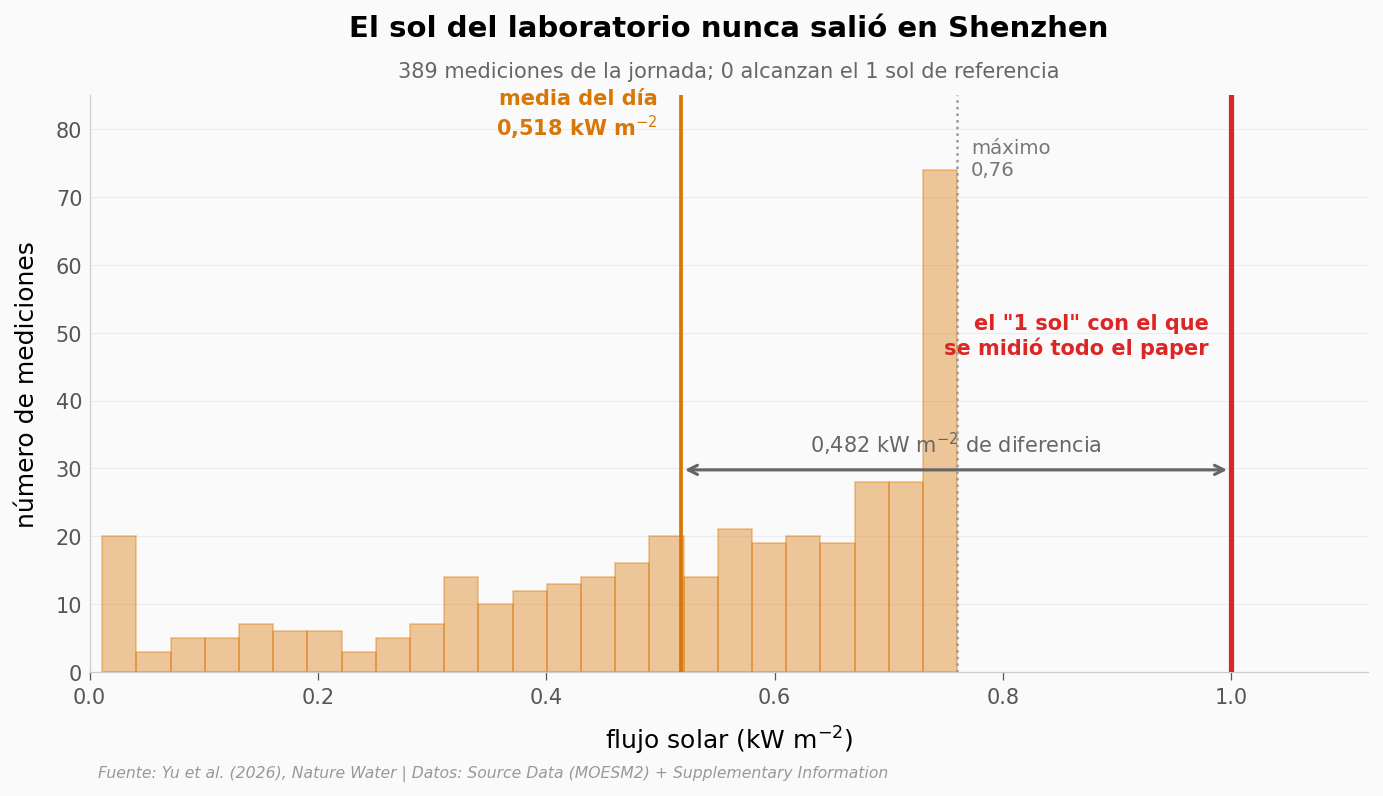

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

n, bins, patches = ax.hist(flujo.flujo_solar_kw_m2, bins=25, color=COLOR_REFERENCIA,
                           alpha=0.4, edgecolor=COLOR_REFERENCIA, linewidth=0.8, zorder=3)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.set_xlim(0, 1.12)

media = flujo.flujo_solar_kw_m2.mean()
ax.axvline(media, color=COLOR_REFERENCIA, linewidth=1.8, zorder=4)
ax.text(media - 0.02, y_max * 0.93, f'media del día\n{media:.3f} kW m'.replace('.', ',') + '$^{-2}$',
        ha='right', fontsize=10, fontweight='bold', color=COLOR_REFERENCIA)

ax.axvline(SOL_LABORATORIO, color=COLOR_ALERTA, linewidth=2.5, zorder=4)
ax.text(SOL_LABORATORIO - 0.02, y_max * 0.55, 'el "1 sol" con el que\nse midió todo el paper',
        ha='right', fontsize=10, fontweight='bold', color=COLOR_ALERTA)

ax.annotate('', xy=(SOL_LABORATORIO, y_max * 0.35), xytext=(media, y_max * 0.35),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + SOL_LABORATORIO) / 2, y_max * 0.38,
        f'{SOL_LABORATORIO - media:.3f} kW m'.replace('.', ',') + '$^{-2}$ de diferencia',
        ha='center', fontsize=10, color='#666666')

ax.axvline(flujo.flujo_solar_kw_m2.max(), color='#999999', linewidth=1.2,
           linestyle=':', zorder=4)
ax.text(flujo.flujo_solar_kw_m2.max() + 0.012, y_max * 0.86,
        f'máximo\n{flujo.flujo_solar_kw_m2.max():.2f}'.replace('.', ','),
        fontsize=9.5, color='#777777')

ax.set_title('El sol del laboratorio nunca salió en Shenzhen', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{len(flujo)} mediciones de la jornada; {sobre_1sol} alcanzan el 1 sol de referencia',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('flujo solar (kW m$^{-2}$)')
ax.set_ylabel('número de mediciones')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sol_real_vs_laboratorio.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

Ninguna de las 389 mediciones llegó al sol de referencia. La media del día fue 0,518 kW m⁻² y el mejor momento tocó 0,76 — tres cuartas partes de un sol de laboratorio. Eso no invalida nada de lo anterior: la jornada exterior se midió tal como fue, y los 19,82 kg de agua salieron con ese sol y no con otro. Lo que sí hace es marcar la distancia entre las dos mitades del paper.

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Bajo 1 sol y con 6 cámaras, la captura de uranio es 11,5 veces la de una cámara a oscuras | ✅ | Recomputado del Source Data: 5,06 / 0,44 g m⁻² = 11,50. El resumen del artículo dice 11,6x (0,9% de desvío). Litio: 7,17 / 0,71 = 10,10 frente a 10,2x anunciado. ⚠️ Medido en solución dopada con 2,5 mg/L, no en agua de mar |
| El salto se puede partir en un factor de luz y un factor de etapas | ✅ | Luz ×3,27 y etapas ×3,51 (uranio); ×3,11 y ×3,24 (litio). Que el producto dé exactamente 11,50 y 10,10 es una identidad algebraica —el valor de una cámara bajo 1 sol se cancela—, no una prueba de que los dos efectos sean independientes: para separarlos harían falta seis cámaras medidas a oscuras, y ese punto no está en los datos publicados |
| El párrafo de resultados del paper reporta otros valores para el mismo salto | ✅ | El cuerpo dice 10,6x y 9,2x; el resumen dice 11,6x y 10,2x. Los datos publicados cuadran con el resumen a menos del 1% |
| Seis cámaras triplican el agua sin costo eléctrico apreciable | ✅ | 1,26 → 4,01 kg m⁻² h⁻¹ (+218%) mientras la salida eléctrica cae 2,0% (124,6 → 122,1 W m⁻²). Ganancia marginal decreciente: +1,01 en la 2.ª cámara, +0,17 en la 6.ª |
| La captura cae piso por piso conforme la cadena se enfría | ✅ | Agua de mar natural: 42,6 → 27,5 °C y ×3,62 (uranio) y ×3,34 (litio) entre la cámara 1 y la 6. ⚠️ ρ de Spearman = 1,00 con n = 6 cámaras del mismo aparato — es descriptivo, no un contraste de hipótesis. La tabla suplementaria no declara a qué superficie se refiere su m⁻², así que solo usamos el gradiente relativo |
| El sistema aguanta 20 ciclos con una degradación leve pero sistemática | ⚠️ | ~40 días: el uranio cae 2,8% y el litio 2,7%, y esa caída es monótona, no dispersión — Spearman ρ = −0,95 y −0,99 frente al número de ciclo. El agua es la única de las tres series sin tendencia detectable (ρ = −0,14, p = 0,55): su −2,0% es solo la diferencia entre el primer ciclo y el último. ⚠️ En agua de mar dopada |
| En la jornada exterior: pico de 154,7 W m⁻² y 19,82 kg m⁻² de agua | ✅ | Ambos en el Source Data. ⚠️ Dos detalles: el resumen escribe el pico como «154,7 W» sin superficie, y la suma de las cinco ventanas da 20,04 kg m⁻² contra los 19,82 reportados (1,1%); las cuatro primeras ventanas coinciden exactas |
| El sol de la jornada nunca alcanzó el «1 sol» del laboratorio | ✅ | 0 de 389 mediciones ≥ 1,0 kW m⁻². Media 0,518, mediana 0,572, RIC 0,389-0,707, máximo 0,760 |
| El aparato rinde un ingreso neto anual superior a US$20 m⁻² | ⚠️ | Es un modelo económico, no un ingreso medido, y el propio análisis de sensibilidad lo condiciona: con mechas capilares de 1 año son US$4,16 m⁻²; los US$20 solo se cruzan a partir de 18 años de vida útil. El paper describe los 20 años como objetivo de diseño, no como vida útil demostrada |
| En agua de mar sin dopar la mejora baja a 1,6x (uranio) y 2,7x (litio) | ⚠️ | Tomado del material suplementario citado en el cuerpo (Fig. 37). No pudimos recomputarlo: esos datos no vienen en el Source Data |

> **Limitaciones**
>
> - **El titular no se midió en agua de mar.** Los 11,5x salen de una solución con 2,5 mg/L del ion diana. El mar tiene 3,33 µg/L de uranio: unas 750 veces menos. Para el litio, 0,18 mg/L, unas 14 veces menos.
> - **La captura absoluta en agua real es diminuta:** 2,63 µmol m⁻² de uranio y 4,50 mmol m⁻² de litio, según las tablas suplementarias. Microgramos y miligramos por metro cuadrado.
> - **La descomposición por campos físicos del paper es semi-cuantitativa** por declaración de los propios autores: los tres campos están acoplados de forma no lineal y el análisis ignora los cruces. Sus conclusiones son de tendencia.
> - **El gradiente por cámara viene de una tabla suplementaria transcrita** (n = 6 cámaras, un solo aparato). Sirve para la forma de la caída, no para totales.
> - **La economía es un modelo con un parámetro dominante** —la vida de la mecha— que no está medido.
> - **Todo lo cuantitativo aquí es un prototipo**, en un patio, un día. Los autores lo plantean como una vía prometedora; nada de esto es una instalación en operación.

## Ahora tú

Tres preguntas que los datos pueden responder:

1. **¿Cuánto del ingreso anual depende de la mecha?** El bloque de configuración tiene `VIDA_MECHA_ANIOS = 5`. Cámbialo y mira cómo se mueve el número. Prueba con `econ.set_index('vida_util_mecha_anios').diff()` para ver dónde la curva deja de subir.

2. **¿Y si el aparato hubiera trabajado bajo un sol de laboratorio todo el día?** El flujo real promedió 0,518 kW m⁻². Prueba escalando la producción de la jornada por `SOL_LABORATORIO / flujo.flujo_solar_kw_m2.mean()` — y luego pregúntate por qué esa regla de tres no es honesta (pista: mira la ganancia marginal decreciente de la gráfica del agua contra la electricidad).

3. **¿Qué campo físico manda?** El paper descompone la mejora en temperatura, concentración y flujo. Descarga `contribucion_campos.csv` del repositorio y compara la columna `flujo_pct` entre la cámara 1 y la 6. ¿El reparto cambia conforme baja la temperatura?

In [7]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto del negocio depende de que la mecha capilar dure?
# El resumen del artículo proyecta "más de US$20 m-2 al año". Esta es la letra pequeña.

curva = econ.set_index('vida_util_mecha_anios').ingreso_neto_usd_m2_anio

print('INGRESO NETO ANUAL MODELADO, según cuánto dure la mecha capilar')
print('  (US$ por metro cuadrado y año)\n')
for anios in [1, 2, 3, VIDA_MECHA_ANIOS, 10, 18, 20]:
    marca = '  <-- el umbral del resumen' if curva[anios] > 20 else ''
    print(f'  {anios:>2} año(s): US${curva[anios]:>6.2f}{marca}')

salto = curva[2] - curva[1]
resto = curva[20] - curva[2]
print(f'\nEl primer año extra de vida útil vale US${salto:.2f}.')
print(f'Los dieciocho siguientes, juntos, valen US${resto:.2f}.')
print(f'La curva se aplana rapidísimo: el {100*salto/(curva[20]-curva[1]):.0f}% de toda la ganancia')
print(f'posible está en pasar de 1 a 2 años.')
print(f'\nY el umbral de US$20 m-2 no se cruza hasta los {primer_20} años de vida útil,')
print('que el propio paper describe como objetivo de diseño y no como vida demostrada.')

# Prueba cambiando VIDA_MECHA_ANIOS arriba y re-ejecutando desde la celda de carga.

INGRESO NETO ANUAL MODELADO, según cuánto dure la mecha capilar
  (US$ por metro cuadrado y año)

   1 año(s): US$  4.16
   2 año(s): US$ 12.56
   3 año(s): US$ 15.36
   5 año(s): US$ 17.60
  10 año(s): US$ 19.28
  18 año(s): US$ 20.03  <-- el umbral del resumen
  20 año(s): US$ 20.12  <-- el umbral del resumen

El primer año extra de vida útil vale US$8.40.
Los dieciocho siguientes, juntos, valen US$7.56.
La curva se aplana rapidísimo: el 53% de toda la ganancia
posible está en pasar de 1 a 2 años.

Y el umbral de US$20 m-2 no se cruza hasta los 18 años de vida útil,
que el propio paper describe como objetivo de diseño y no como vida demostrada.


## Fuentes

**Paper**: [Solar-powered resource separator for clean water production, electricity generation and critical resource recovery](https://doi.org/10.1038/s44221-026-00700-2)  
*Nature Water, 2026-09-01*

**Supplementary Material**: [Supplementary Information — Supp Tables 4, 5, 6 y 7 (gradiente por camara, selectividad, costos)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs44221-026-00700-2/MediaObjects/44221_2026_700_MOESM1_ESM.pdf)  
*Mismo DOI que el artículo — tablas suplementarias 4, 5, 6 y 7*

**Datos**: [Source Data for: Solar-powered resource separator — 21 hojas, una por panel de figura](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs44221-026-00700-2/MediaObjects/44221_2026_700_MOESM2_ESM.xlsx)  
*Una hoja por panel de figura; de ahí salen los 10 CSV de este notebook*

*20 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [El Lab](https://cienciaamordiscos.com) — Ciencia a Mordiscos. Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Reproducible de punta a punta: los CSV se descargan solos.*